## Pennsylvania - 2 pfts 

#### Libraries

In [19]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

In [20]:
dark = cm.get_cmap('Paired', 12)
colormap = dark(range(12))

#### Load the FATES runs  
- note we did this in four cases each with 250 members

In [21]:
fates1='/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ensemble_1_v3.Eddc844b10d-Fd554ed4a.2025-03-19/run/PA_ensemble_1_v3.Eddc844b10d-Fd554ed4a.2025-03-19.h0.ensemble.sofar.nc'
fates1 = xr.open_dataset(fates1,  decode_times=False)

fates2='/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ensemble_2_v3.Eddc844b10d-Fd554ed4a.2025-03-19/run/PA_ensemble_2_v3.Eddc844b10d-Fd554ed4a.2025-03-19.h0.ensemble.sofar.nc'
fates2 = xr.open_dataset(fates2,  decode_times=False)

#fates = xr.concat([fates1, fates2], dim='record')

In [4]:
nyears = int(len(fates1.variables['time']))
print(nyears)

nyears = int(len(fates2.variables['time']))
print(nyears)

3600
3600


In [5]:
fates = xr.concat([fates1, fates2], dim='record')

In [22]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = fates.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

print(tave_start)
print(tave_stop)

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]

n_lon = len(fates.variables['lon'])
ninst = n_lon
print(ninst)

300
3360
3600
500


### Veg C through time 

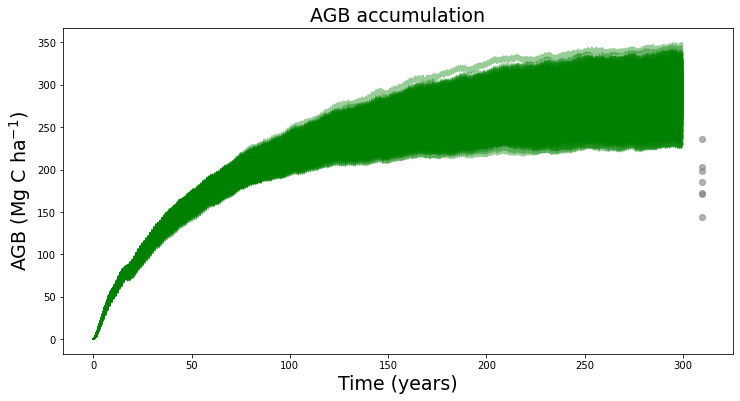

In [23]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

for  i in range(0,ninst):
    if i == 0: 
        f1ax0.plot(time, AGB[i], color='green', label = 'FATES', alpha = 0.4)    
    else: 
        f1ax0.plot(time, AGB[i,:], color='green', alpha = 0.4)

f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
;

gedi_x = [310,310,310,310,310,310,310]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16] # Mg ha-1 - aboveground biomass density 

f1ax0.scatter(gedi_x, gedi_y, alpha=0.6, color='grey')

### Ensemble members within 10% of GEDI  mean

In [24]:
gedi_mean = np.mean(gedi_y)
print(gedi_mean)

187.32


In [25]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')
print(AGB.shape)
AGB_tend = np.squeeze(AGB.isel(time=slice(tave_start,tave_stop)).mean(dim='time'))
print(AGB_tend.shape)

(500, 3600, 1)
(500,)


###  Ensemble members with coexistence, early cross over point and lowest biomass

In [12]:
# find ensemble where ST > LD in year 100 

In [26]:
vegc = fates.FATES_VEGC_PF

coex = []
total300 = []

for i in range(0,ninst):
    veg =  vegc.isel(record=i)
    # percent total  biomass of each tree PFT
    vegc100 = veg.isel(time=1190)
    vegc50 = veg.isel(time=600)
    
    
    total100 = vegc100.sum(dim=('fates_levpft'))
    pft1_100 = (vegc100.isel(fates_levpft=0)  / total100 ).values
    total50 = vegc50.sum(dim=('fates_levpft'))
    pft1_50 = (vegc50.isel(fates_levpft=0)  / total50 ).values

    if (pft1_50 > 0.5 and pft1_100 < 0.5 ) :
        coex.append(i)
        total300.append(veg.isel(time=1199).sum(dim='fates_levpft'))
    
        
print(len(coex)) 
print(len(total300))

172
172


(500, 3600, 2, 1)


IndexError: index 64 is out of bounds for axis 0 with size 64

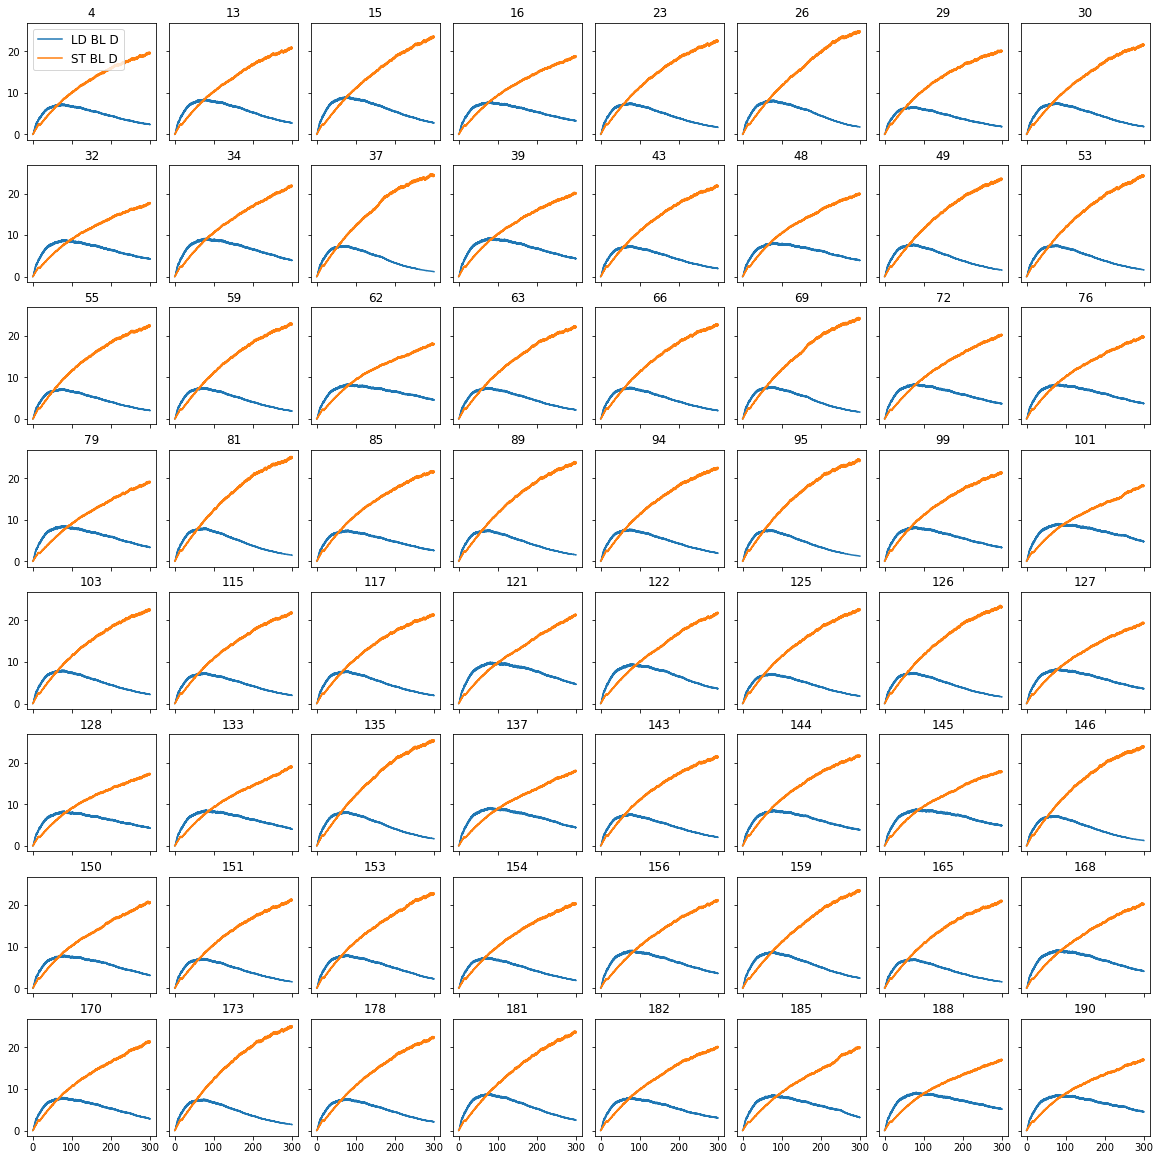

In [14]:
AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=8,ncols=8, figsize=(16,16), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(coex)):
    axs[i].plot(time, AGB[coex[i],:,0],label = 'LD BL D')  
    axs[i].plot(time, AGB[coex[i],:,1], label = 'ST BL D')      
    axs[i].set_title(coex[i])
    if i == 0:
        axs[i].legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

### Which of these has the lowest biomass? 

In [27]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')
AGB = AGB.sel(record = coex)
AGB = np.squeeze(AGB.isel(time=slice(3479,3599)).mean(dim='time'))

In [28]:
np.where(AGB == np.min(AGB))

(array([159]),)

In [29]:
coex[159]

460

In [30]:
fates_best = fates.isel(record=460)

### Size distribution

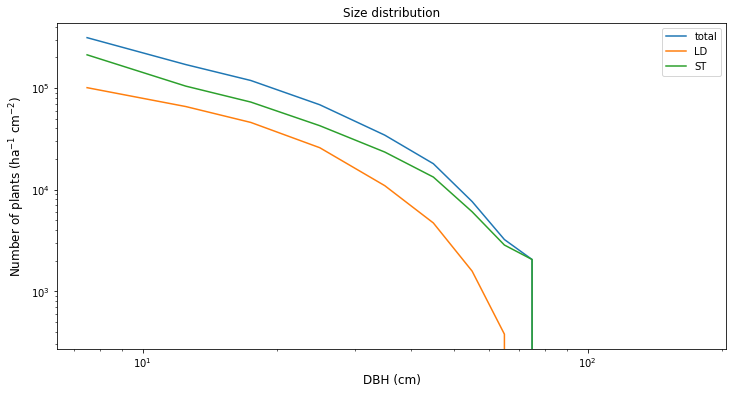

In [31]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

nplant = NPLANT_SZ.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000 # convert to plants per ha (from m-2)
nplant = np.squeeze(nplant)
fates_sd = np.squeeze(nplant[1:,])/fates_sizebin_widths

nplant1 = NPLANT_SZPF.isel(fates_levpft=0)
nplant2 = NPLANT_SZPF.isel(fates_levpft=1)

nplant1 = nplant1.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant2 = nplant2.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant1 = np.squeeze(nplant1)
nplant2 = np.squeeze(nplant2)

fates_sd1 = np.squeeze(nplant1[1:,])/fates_sizebin_widths
fates_sd2 = np.squeeze(nplant2[1:,])/fates_sizebin_widths

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(fates_sizebin_mids, fates_sd,  label = 'total')
f2ax0.plot(fates_sizebin_mids, fates_sd1,  label = 'LD')
f2ax0.plot(fates_sizebin_mids, fates_sd2,  label = 'ST')
    
f2ax0.set_title(r'Size distribution', fontsize = 12)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 12)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend()
f2ax0.set_yscale('log')
f2ax0.set_xscale('log')

### Population size and AGB through time by size

(3600, 1, 13)


Text(0, 0.5, 'Cohort Size (cm)')

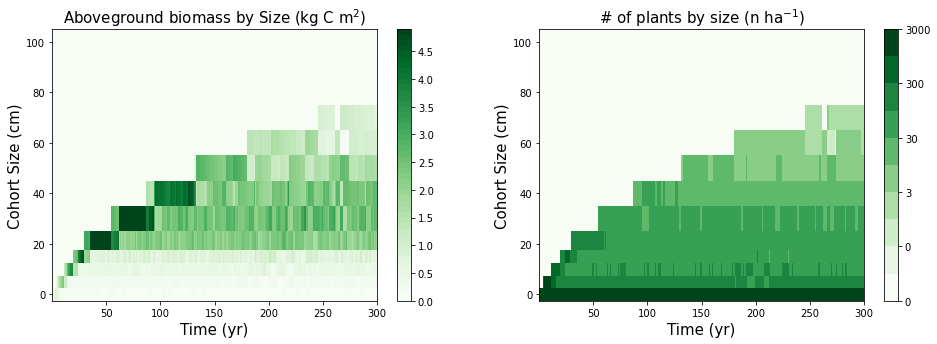

In [32]:
# population numbers as a function of cohort size
NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_VEGC_ABOVEGROUND_SZPF, fates_best)
VEGC_ABOVEGROUND_SZ  = VEGC_ABOVEGROUND_SZPF.sum(dim='fates_levpft')
print(VEGC_ABOVEGROUND_SZ.shape)

fig2, ((f2ax0, f2ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(16,5))

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,5, 0.1)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax0.pcolormesh(time, cohort_size_bins, VEGC_ABOVEGROUND_SZ[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'Aboveground biomass by Size (kg C m$^2$)', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax1.pcolormesh(time, cohort_size_bins, (NPLANT_SZ)[:,0,:].transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'# of plants by size (n ha$^{-1}$)', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)

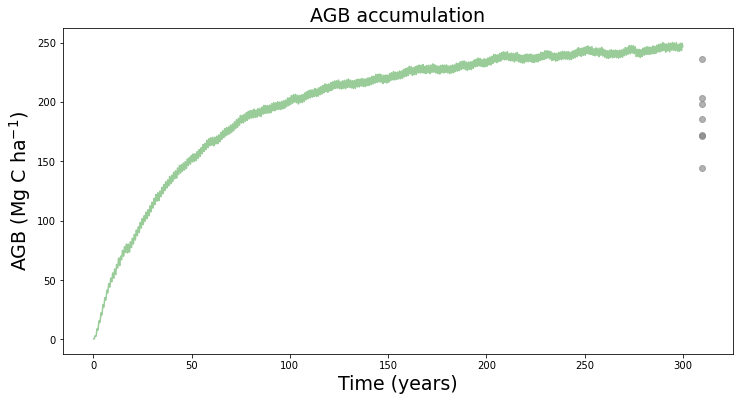

In [34]:
AGB = fates_best.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, AGB, color='green', label = 'FATES', alpha = 0.4)    
    
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    


gedi_x = [310,310,310,310,310,310,310]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16] # Mg ha-1 - aboveground biomass density 

f1ax0.scatter(gedi_x, gedi_y, alpha=0.6, color='grey')

Text(0.02, 0.5, 'Vegc (kg C m-2)')

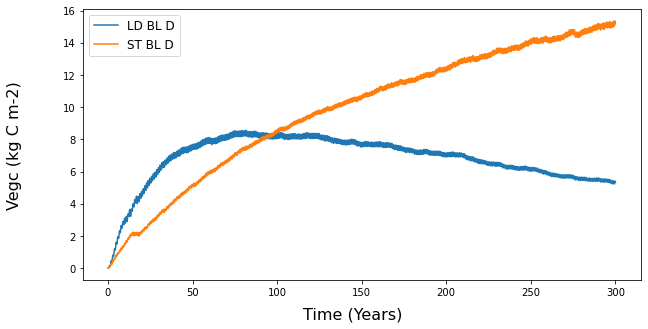

In [35]:
AGB = fates_best.FATES_VEGC_PF

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(10,5))


axs.plot(time, AGB.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, AGB.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

### Growth and mortality 

In [36]:
def szpf_to_scls_by_pft(scpf_var, dataset):
    """function to reshape a fates multiplexed size and pft-indexed variable to one indexed by size class and pft
    first argument should be an xarray DataArray that has the FATES SCPF dimension
    second argument should be an xarray Dataset that has the FATES SCLS dimension 
    (possibly the dataset encompassing the dataarray being transformed)
    returns an Xarray DataArray with the size and pft dimensions disentangled"""
    n_scls = len(dataset.fates_levscls)
    ds_out = (scpf_var.rolling(fates_levscpf=n_scls, center=False)
            .construct("fates_levscls")
            .isel(fates_levscpf=slice(n_scls-1, None, n_scls))
            .rename({'fates_levscpf':'fates_levpft'})
            .assign_coords({'fates_levscls':dataset.fates_levscls})
            .assign_coords({'fates_levpft':dataset.fates_levpft}))
    ds_out.attrs['long_name'] = scpf_var.attrs['long_name']
    ds_out.attrs['units'] = scpf_var.attrs['units']
    return(ds_out)

In [37]:
dark = cm.get_cmap('Paired', 12)
colormap = dark(range(12))

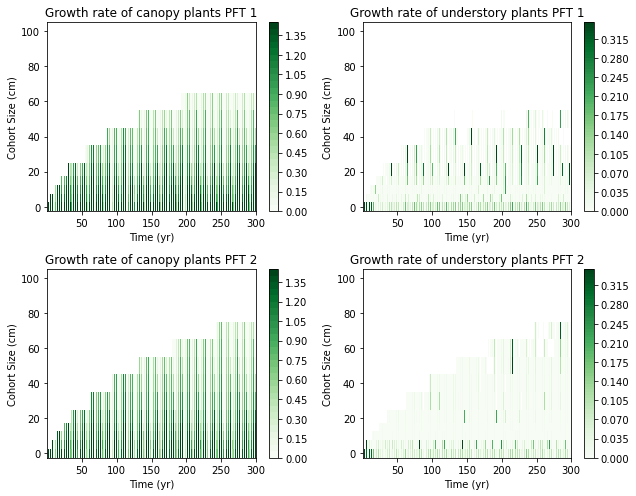

In [39]:
NPLANT_CANOPY_SZPF = szpf_to_scls_by_pft(fates_best.FATES_NPLANT_CANOPY_SZPF, fates_best) 
NPLANT_USTORY_SZPF = szpf_to_scls_by_pft(fates_best.FATES_NPLANT_USTORY_SZPF, fates_best)

DDBH_CANOPY_SZPF = szpf_to_scls_by_pft(fates_best.FATES_DDBH_CANOPY_SZPF, fates_best) * 100 # convert to cm
DDBH_USTORY_SZPF = szpf_to_scls_by_pft(fates_best.FATES_DDBH_USTORY_SZPF, fates_best) * 100 # convert to cm

MORT_CANOPY_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_CANOPY_SZPF, fates_best)
MORT_USTORY_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_USTORY_SZPF, fates_best)

# set up the page
fig3, ((f3ax0, f3ax1), (f3ax2, f3ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,1.5, 0.05)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_CANOPY_SZPF.isel(fates_levpft=0) / NPLANT_CANOPY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Growth rate of canopy plants PFT 1')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.35, 0.005)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_USTORY_SZPF.isel(fates_levpft=0) / NPLANT_USTORY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'Growth rate of understory plants PFT 1')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

levels = np.arange(0.,1.5, 0.05)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_CANOPY_SZPF.isel(fates_levpft=1) / NPLANT_CANOPY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Growth rate of canopy plants PFT 2')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.35, 0.005)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_USTORY_SZPF.isel(fates_levpft=1) / NPLANT_USTORY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Growth rate of understory plants PFT 2')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

fig3.tight_layout()

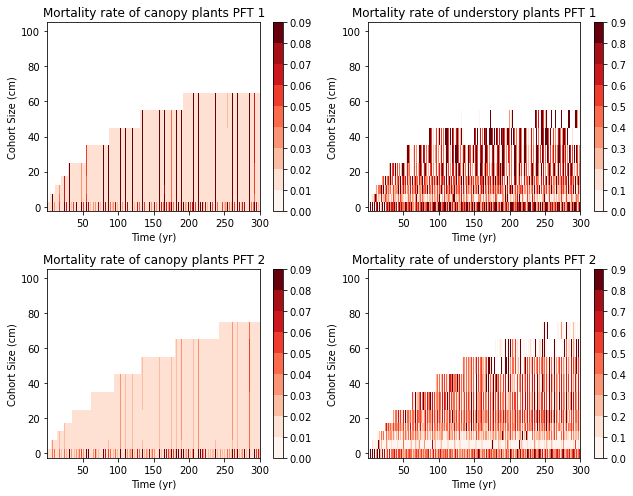

In [40]:
# set up the page
fig3, ((f3ax0, f3ax1), (f3ax2, f3ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_CANOPY_SZPF.isel(fates_levpft=0) / NPLANT_CANOPY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Mortality rate of canopy plants PFT 1')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,1.0, 0.1)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_USTORY_SZPF.isel(fates_levpft=0) / NPLANT_USTORY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'Mortality rate of understory plants PFT 1')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_CANOPY_SZPF.isel(fates_levpft=1) / NPLANT_CANOPY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Mortality rate of canopy plants PFT 2')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,1.0, 0.1)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_USTORY_SZPF.isel(fates_levpft=1) / NPLANT_USTORY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Mortality rate of understory plants PFT 2')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

fig3.tight_layout()

In [42]:
MORT_B_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_BACKGROUND_SZPF, fates_best)
MORT_C_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_CSTARV_SZPF, fates_best)
MORT_T_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_TERMINATION_SZPF, fates_best)
MORT_I_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_IMPACT_SZPF, fates_best)
MORT_H_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_HYDRAULIC_SZPF, fates_best)
MORT_F_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_FREEZING_SZPF, fates_best)
NPLANT_SZPF = szpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) 

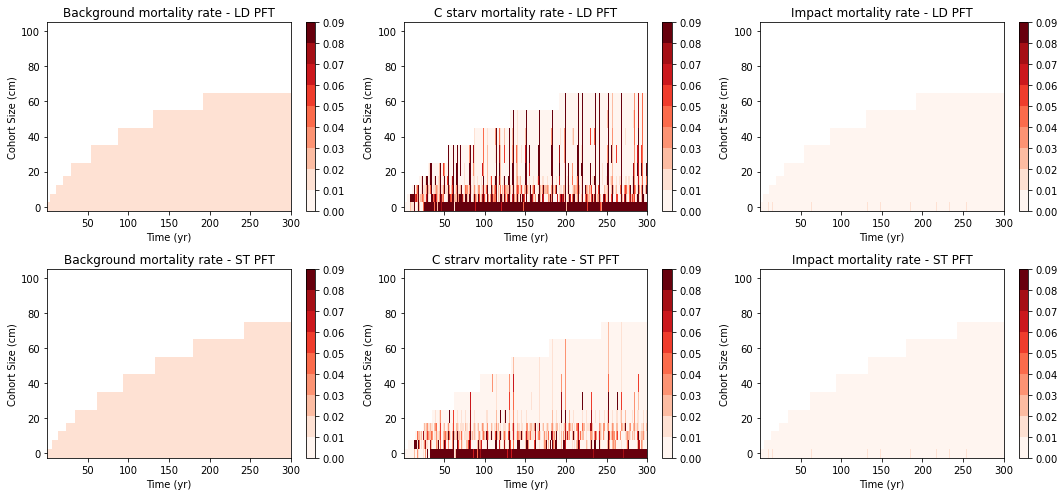

In [53]:
# set up the page
fig3, ((f3ax0, f3ax1, f3ax2), (f3ax3, f3ax4, f3ax5)) = plt.subplots(nrows=2, ncols=3, figsize=(15, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_B_SZPF.isel(fates_levpft=0) / NPLANT_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Background mortality rate - LD PFT')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_C_SZPF.isel(fates_levpft=0) / NPLANT_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'C starv mortality rate - LD PFT')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_I_SZPF.isel(fates_levpft=0) / NPLANT_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Impact mortality rate - LD PFT')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')


## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_B_SZPF.isel(fates_levpft=1) / NPLANT_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Background mortality rate - ST PFT')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax4.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_C_SZPF.isel(fates_levpft=1) / NPLANT_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax4)
f3ax4.set_title(r'C strarv mortality rate - ST PFT')
f3ax4.set_xlabel('Time (yr)')
f3ax4.set_ylabel('Cohort Size (cm)')


## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax5.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_I_SZPF.isel(fates_levpft=1) / NPLANT_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax5)
f3ax5.set_title(r'Impact mortality rate - ST PFT')
f3ax5.set_xlabel('Time (yr)')
f3ax5.set_ylabel('Cohort Size (cm)')


fig3.tight_layout()

#### Recruitment

Text(0.02, 0.5, 'Recruitment (kg C m-2)')

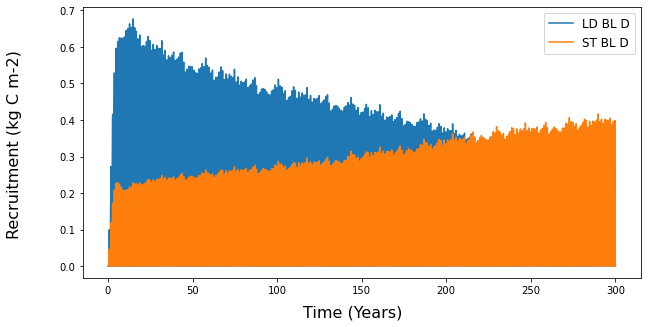

In [55]:
recruit = fates_best.FATES_RECRUITMENT_PF

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(10,5))


axs.plot(time, recruit.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, recruit.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Recruitment (kg C m-2)', fontsize=16)